# 01 — Data preparation and source audit

## Purpose of this notebook

This notebook creates the match-level table used by the rest of the thesis project. Its task is deliberately limited to **data preparation and validation**. Exploratory analysis of modelling variables belongs to Notebook 02, while feature selection belongs to Notebook 03.

The analysis covers the Premier League, La Liga, Bundesliga, Serie A, and Ligue 1. The modelling experiment uses three development seasons, 2021/22–2023/24, and one untouched final season, 2024/25. The latter is predicted retrospectively in chronological order in Notebook 06.

The main questions answered here are:

1. Which source provides each group of variables?
2. Was the information available before the predicted match?
3. Do the joins preserve one row per match?
4. How complete is each external source?
5. How many matches are predicted in 2024/25, and between which dates?

No model is fitted and no decision is made from the 2024/25 outcomes in this notebook.

## 1. Data sources and their role

The project uses four source families. Raw snapshots are stored as CSV files, so the analysis can be rerun without silently downloading a newer version of the source.

| Source | Variables used in this project | Time meaning | Role in later models |
|---|---|---|---|
| [Understat](https://understat.com/) through [soccerdata](https://soccerdata.readthedocs.io/) | fixture date, teams, final score, xG, non-penalty xG, expected points, PPDA, deep completions | Match statistics are created during or after the match. Therefore, statistics of match $i$ may describe only later matches, never match $i$ itself. | Targets and lagged structural features |
| [ClubElo](http://clubelo.com/) | team Elo rating and competition level | The join uses a rating interval valid on the match date. | Pre-match structural team strength |
| Public EA Sports player datasets: [FIFA 15–FC 24](https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset) and [FC 25](https://www.kaggle.com/datasets/nyagami/ea-sports-fc-25-database-ratings-and-stats) | squad size and aggregates for the best goalkeeper, defenders, midfielders, attackers, top 11, and top 15 players | The latest public snapshot on or before the match date is used. FC 25 values become eligible only from its public release date, 27 September 2024. | Pre-match structural squad strength |
| [Football-Data](https://www.football-data.co.uk/data.php) | decimal 1X2 odds, bookmaker margin, and normalised home/draw/away probabilities | The archived files describe pre-match or closing prices, but do not provide a reliable exact collection timestamp for every historical match. | Additional inputs of the market-enriched branch |

This distinction is important. A variable can be present in a historical file and still be invalid for prediction if it became known only after kick-off. Notebook 02 therefore constructs all performance features with an explicit lag.

### 1.1 Prediction targets

Let $G_{H,i}$ and $G_{A,i}$ be the final numbers of goals scored by the home and away team in match $i$. The multiclass target is

$$
Z_i =
\begin{cases}
H, & G_{H,i} > G_{A,i},\\
D, & G_{H,i} = G_{A,i},\\
A, & G_{H,i} < G_{A,i}.
\end{cases}
$$

Here, $H$ denotes a home win, $D$ a draw, and $A$ an away win. The secondary binary target is $Y_i=\mathbb{1}(Z_i=H)$, so $Y_i=1$ means a home win and $Y_i=0$ means a home non-win. These outcomes are retained for later evaluation but are never used as pre-match explanatory variables for the same match.

## 2. Reproducible project setup

The following cell imports the reusable joining functions from `src`. A normal run reads the stored CSV snapshots. Source refresh is intentionally a separate, explicit action because a new download could change the empirical sample.

In [1]:
from pathlib import Path
import os
import sys
import tempfile

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "match_prediction_matplotlib"),
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    DEVELOPMENT_SEASONS,
    FINAL_TEST_SEASON,
    INTERIM_DATA_DIR,
)
from src.data_acquisition import load_understat_top5
from src.data_builder import attach_external_data, build_understat_rich_matches
from src.external_data import load_external_tables

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 60)

COLORS = {
    "clubelo": "#1F4E79",
    "sofifa": "#2A9D8F",
    "market": "#E9C46A",
    "accent": "#C44E52",
}

## 3. Load the stored source snapshots

The row count describes the granularity of each source. The two Understat tables contain one row per match. ClubElo and SoFIFA contain repeated dated observations per team, while Football-Data again contains one row per match. Different row counts are therefore expected and do not by themselves signal a quality problem.

In [2]:
schedule, team_stats = load_understat_top5()
external = load_external_tables()

source_overview = pd.DataFrame(
    [
        ("Understat schedule", "one row per match", len(schedule), schedule.shape[1]),
        ("Understat team statistics", "one row per match", len(team_stats), team_stats.shape[1]),
        ("ClubElo history", "dated interval per team", len(external["clubelo"]), external["clubelo"].shape[1]),
        ("SoFIFA squad ratings", "dated snapshot per team", len(external["sofifa"]), external["sofifa"].shape[1]),
        ("Football-Data odds", "one row per match", len(external["market"]), external["market"].shape[1]),
    ],
    columns=["source", "observation_unit", "rows", "columns"],
)
source_overview.style.format({"rows": "{:,}", "columns": "{:,}"})

,source,observation_unit,rows,columns
0,Understat schedule,one row per match,"19,864",17
1,Understat team statistics,one row per match,"19,762",26
2,ClubElo history,dated interval per team,"129,199",8
3,SoFIFA squad ratings,dated snapshot per team,"1,051",12
4,Football-Data odds,one row per match,"19,465",16


The overview should not be read as five competing datasets. They provide complementary information that is combined around a single match key.

### 3.1 Representative source rows

`sample(random_state=42)` is used because the first rows may all come from one league or season. The selected columns show the intended content without printing very wide raw tables.

In [3]:
schedule_sample = schedule[
    ["league_id", "season_id", "game_id", "date", "home_team", "away_team", "home_goals", "away_goals", "home_xg", "away_xg"]
].sample(5, random_state=42).sort_values("date")
schedule_sample

,league_id,season_id,game_id,date,home_team,away_team,home_goals,away_goals,home_xg,away_xg
5748,4,2019,12068,2019-09-22 19:00:00,Sevilla,Real Madrid,0.0,1.0,0.394624,1.239160
10504,5,2020,16001,2021-02-14 14:00:00,Metz,Strasbourg,1.0,2.0,1.466060,1.396720
6311,4,2020,15015,2021-02-20 17:30:00,Valencia,Celta Vigo,2.0,0.0,1.166750,0.689216
10952,5,2021,18140,2022-04-16 15:00:00,Saint-Etienne,Brest,2.0,1.0,1.844620,0.488405
11436,5,2023,23407,2023-09-15 19:00:00,Paris Saint Germain,Nice,2.0,3.0,1.219290,1.949850


Each schedule row identifies one match and contains its outcome. The xG columns are match outcomes as well; they will be lagged before they can become predictors.

In [4]:
external_examples = pd.concat(
    [
        external["clubelo"].sample(2, random_state=42).assign(source="ClubElo").rename(
            columns={"rating_from": "information_date", "clubelo_rating": "main_value"}
        )[["source", "information_date", "team", "main_value"]],
        external["sofifa"].sample(2, random_state=42).assign(source="SoFIFA").rename(
            columns={"rating_date": "information_date", "sofifa_top11_overall": "main_value"}
        )[["source", "information_date", "team", "main_value"]],
        external["market"].sample(2, random_state=42).assign(source="Football-Data").rename(
            columns={"date": "information_date", "home_team": "team", "market_prob_home": "main_value"}
        )[["source", "information_date", "team", "main_value"]],
    ],
    ignore_index=True,
)
external_examples.sort_values(["source", "information_date"])

,source,information_date,team,main_value
0,ClubElo,2018-02-05,Werder Bremen,1630.362671
1,ClubElo,2024-04-14,Aston Villa,1828.630981
5,Football-Data,2023-05-27,Bochum,0.236243
4,Football-Data,2025-02-16,FC Heidenheim,0.257622
2,SoFIFA,2015-09-21,Fiorentina,78.727273
3,SoFIFA,2024-09-27,Newcastle United,82.727273


The meaning of `main_value` depends on the source: it is an Elo rating, a top-11 squad rating, or the market-implied probability of a home win. The common purpose of the display is only to verify identifiers, dates, and numerical formatting.

## 4. Build one match-level table

The first join combines the Understat schedule with team match statistics using `(league_id, season_id, game_id)`. It is validated as one-to-one. The second stage attaches both teams' latest eligible ClubElo and SoFIFA observations and joins Football-Data on league, date, and team names.

The `sample_role` is assigned from `season_id` in reusable source code:

- 2021/22–2023/24: `development`;
- 2024/25: `walk_forward_test`;
- earlier rows: `context_only`;
- rows after 2024/25: `outside_study`.

The context rows remain useful for calculating lagged history but cannot determine the final model. Rows outside the study are retained in the raw merge only and are excluded from all thesis experiments.

In [5]:
matches = build_understat_rich_matches(schedule, team_stats)
matches = attach_external_data(
    matches,
    external["clubelo"],
    external["sofifa"],
    external["market"],
)

matches["covid_restrictions"] = matches["date"].between(
    pd.Timestamp("2020-03-13"), pd.Timestamp("2021-06-30")
).astype("Int8")

market_source = matches["market_odds_source"].astype("string")
matches["market_time_type"] = np.select(
    [market_source.str.contains("closing", na=False), market_source.notna()],
    ["closing_price_no_timestamp", "pre_match_price_no_timestamp"],
    default="not_available",
)
matches["market_time_type"] = matches["market_time_type"].astype("string")

print(f"Match table shape: {matches.shape[0]:,} rows × {matches.shape[1]} columns")
matches[
    [
        "league_id", "season_id", "date", "home_team", "away_team",
        "home_goals", "away_goals", "target_1x2",
        "home_clubelo_rating", "away_clubelo_rating",
        "home_sofifa_top11_overall", "away_sofifa_top11_overall",
        "market_prob_home", "market_prob_draw", "market_prob_away",
        "sample_role",
    ]
].sample(8, random_state=42).sort_values(["season_id", "date"])

Match table shape: 19,761 rows × 88 columns


,league_id,season_id,date,home_team,away_team,home_goals,away_goals,target_1x2,home_clubelo_rating,away_clubelo_rating,home_sofifa_top11_overall,away_sofifa_top11_overall,market_prob_home,market_prob_draw,market_prob_away,sample_role
8164,LALIGA,2016,2017-02-28,Real Sociedad,Eibar,2,2,D,NaN,NaN,79.0,76.363636,0.542466,0.275032,0.182502,context_only
1034,BUNDESLIGA,2018,2018-12-03,Nuernberg,Bayer Leverkusen,1,1,D,1522.921143,1689.511475,72.272727,81.272727,0.194609,0.239666,0.565724,context_only
14130,LIGUE_1,2021,2022-02-06,Nice,Clermont Foot,0,1,A,1690.342651,1537.112549,77.545455,72.090909,0.575934,0.242652,0.181414,development
18628,SERIE_A,2023,2023-08-20,Lecce,Lazio,2,1,H,1579.243042,1779.98584,73.363636,80.545455,0.256485,0.294366,0.449149,development
2578,BUNDESLIGA,2023,2023-12-16,RasenBallsport Leipzig,Hoffenheim,3,1,H,1847.075684,1674.371338,81.0,77.090909,0.717308,0.164026,0.118666,development
18810,SERIE_A,2023,2024-01-07,Roma,Atalanta,1,1,D,1770.125122,1767.711914,81.636364,79.363636,0.420414,0.302965,0.276620,development
11647,LALIGA,2025,2026-04-11,Real Sociedad,Alaves,3,3,D,1707.099854,1628.619629,80.0,74.545455,0.516203,0.261696,0.222101,outside_study
7497,EPL,2025,2026-04-22,Burnley,Manchester City,0,1,A,1666.231934,1966.487061,75.272727,87.636364,0.059988,0.116866,0.823145,outside_study


The representative rows verify that the final outcome, structural strength measures, market probabilities, and sample role coexist on one record. Their coexistence does **not** authorise the outcome columns as predictors; the allowed input sets are defined explicitly in Notebook 02.

## 5. Format and chronological-order checks

Dates must be real datetime values, identifiers and labels must be stable, and numerical measures must remain numerical. The next table focuses on variables that represent the main families of columns.

In [6]:
format_check = pd.DataFrame(
    {
        "dtype": matches.dtypes.astype(str),
        "missing_values": matches.isna().sum(),
        "missing_share": matches.isna().mean(),
    }
)

format_columns = [
    "date", "league_id", "season_id", "game_id", "home_team", "away_team",
    "home_goals", "home_xg", "target_1x2", "home_win",
    "home_clubelo_rating", "home_sofifa_top11_overall", "market_prob_home",
    "sample_role",
]
format_check.loc[format_columns].style.format({"missing_share": "{:.1%}"})

,dtype,missing_values,missing_share
date,datetime64[us],0,0.0%
league_id,str,0,0.0%
season_id,int64,0,0.0%
game_id,int64,0,0.0%
home_team,str,0,0.0%
away_team,str,0,0.0%
home_goals,int64,0,0.0%
home_xg,float64,0,0.0%
target_1x2,string,0,0.0%
home_win,Int8,0,0.0%


Missing external ratings are expected where a source has no valid earlier observation. They will be handled inside the modelling pipelines rather than filled from future information.

Unlike the representative displays above, `head()` is appropriate for the next check because the purpose is specifically to inspect the first rows after chronological sorting.

In [7]:
chronological_check = matches.sort_values(["league_id", "date", "game_id"])[
    ["league_id", "date", "game_id", "home_team", "away_team"]
]
chronological_check.head(8)

,league_id,date,game_id,home_team,away_team
0,BUNDESLIGA,2015-08-14,1021,Bayern Munich,Hamburger SV
1,BUNDESLIGA,2015-08-15,1022,Bayer Leverkusen,Hoffenheim
2,BUNDESLIGA,2015-08-15,1023,Augsburg,Hertha Berlin
3,BUNDESLIGA,2015-08-15,1024,Werder Bremen,Schalke 04
4,BUNDESLIGA,2015-08-15,1025,Mainz 05,Ingolstadt
5,BUNDESLIGA,2015-08-15,1026,Darmstadt,Hannover 96
6,BUNDESLIGA,2015-08-15,1027,Borussia Dortmund,Borussia M.Gladbach
7,BUNDESLIGA,2015-08-16,1028,Wolfsburg,Eintracht Frankfurt


The ordering is league first and time second. Notebook 02 will use the date and match identifier to update rolling histories only after a match has been completed.

## 6. Join integrity and leakage-boundary checks

The following diagnostics test properties that must hold exactly or almost exactly. A duplicate match key would invalidate the unit of observation. A disagreement between joined final scores would indicate a wrong team/date match. Normalised market probabilities should sum to one up to numerical precision.

In [8]:
key_columns = ["league_id", "season_id", "game_id"]
joined_market = matches["market_score_agrees"].notna()

integrity_checks = pd.DataFrame(
    [
        ("Duplicate match keys", matches.duplicated(key_columns).sum(), "must equal 0"),
        ("Missing date or team identifier", matches[["date", "home_team", "away_team"]].isna().any(axis=1).sum(), "must equal 0"),
        ("Joined market rows with score disagreement", matches["market_score_agrees"].eq(0).sum(), "must be negligible"),
        ("Largest market probability-sum error", (matches.loc[matches["market_available"].eq(1), "market_probability_sum"] - 1).abs().max(), "approximately 0"),
        ("ClubElo rows starting after match date", ((matches["home_rating_from"] > matches["date"]) | (matches["away_rating_from"] > matches["date"])).sum(), "must equal 0"),
        ("SoFIFA rows dated after match date", ((matches["home_rating_date"] > matches["date"]) | (matches["away_rating_date"] > matches["date"])).sum(), "must equal 0"),
    ],
    columns=["diagnostic", "observed_value", "requirement"],
)
integrity_checks

,diagnostic,observed_value,requirement
0,Duplicate match keys,0.000000e+00,must equal 0
1,Missing date or team identifier,0.000000e+00,must equal 0
2,Joined market rows with score disagreement,2.000000e+00,must be negligible
3,Largest market probability-sum error,4.440892e-16,approximately 0
4,ClubElo rows starting after match date,0.000000e+00,must equal 0
5,SoFIFA rows dated after match date,0.000000e+00,must equal 0


Zero future-dated ClubElo and SoFIFA joins confirm that the as-of joins respect the calendar boundary. The check cannot establish an exact intraday timestamp when a provider publishes only a date; this limitation is reported rather than hidden.

## 7. Source coverage in the modelling experiment

Coverage is calculated at match level. A source is counted as available only when the required values exist for both teams (or all three market probabilities exist). The table separates development from final testing so that a high overall rate cannot hide a weak league-season combination.

In [9]:
study_rows = matches.loc[
    matches["season_id"].isin([*DEVELOPMENT_SEASONS, FINAL_TEST_SEASON])
].copy()
coverage = (
    study_rows.groupby(["season_id", "sample_role", "league_id"], observed=True)
    .agg(
        matches=("game_id", "size"),
        first_match=("date", "min"),
        last_match=("date", "max"),
        clubelo_coverage=("clubelo_available", "mean"),
        sofifa_coverage=("sofifa_available", "mean"),
        market_coverage=("market_available", "mean"),
    )
    .reset_index()
)
coverage.style.format(
    {
        "clubelo_coverage": "{:.1%}",
        "sofifa_coverage": "{:.1%}",
        "market_coverage": "{:.1%}",
        "first_match": lambda value: value.strftime("%d %b %Y"),
        "last_match": lambda value: value.strftime("%d %b %Y"),
    }
)

,season_id,sample_role,league_id,matches,first_match,last_match,clubelo_coverage,sofifa_coverage,market_coverage
0,2021,development,BUNDESLIGA,306,13 Aug 2021,14 May 2022,100.0%,96.7%,100.0%
1,2021,development,EPL,380,13 Aug 2021,22 May 2022,100.0%,98.7%,100.0%
2,2021,development,LALIGA,380,13 Aug 2021,22 May 2022,100.0%,100.0%,99.7%
3,2021,development,LIGUE_1,380,06 Aug 2021,21 May 2022,100.0%,98.2%,99.7%
4,2021,development,SERIE_A,380,21 Aug 2021,22 May 2022,100.0%,96.3%,100.0%
5,2022,development,BUNDESLIGA,306,05 Aug 2022,27 May 2023,100.0%,100.0%,100.0%
6,2022,development,EPL,380,05 Aug 2022,28 May 2023,90.0%,98.2%,100.0%
7,2022,development,LALIGA,380,12 Aug 2022,04 Jun 2023,100.0%,100.0%,100.0%
8,2022,development,LIGUE_1,380,05 Aug 2022,03 Jun 2023,90.0%,95.8%,99.7%
9,2022,development,SERIE_A,380,13 Aug 2022,04 Jun 2023,100.0%,96.3%,100.0%


The detailed table is the primary audit record. The heatmap below summarises the same information visually; darker cells mean higher coverage. It measures availability, not predictive usefulness.

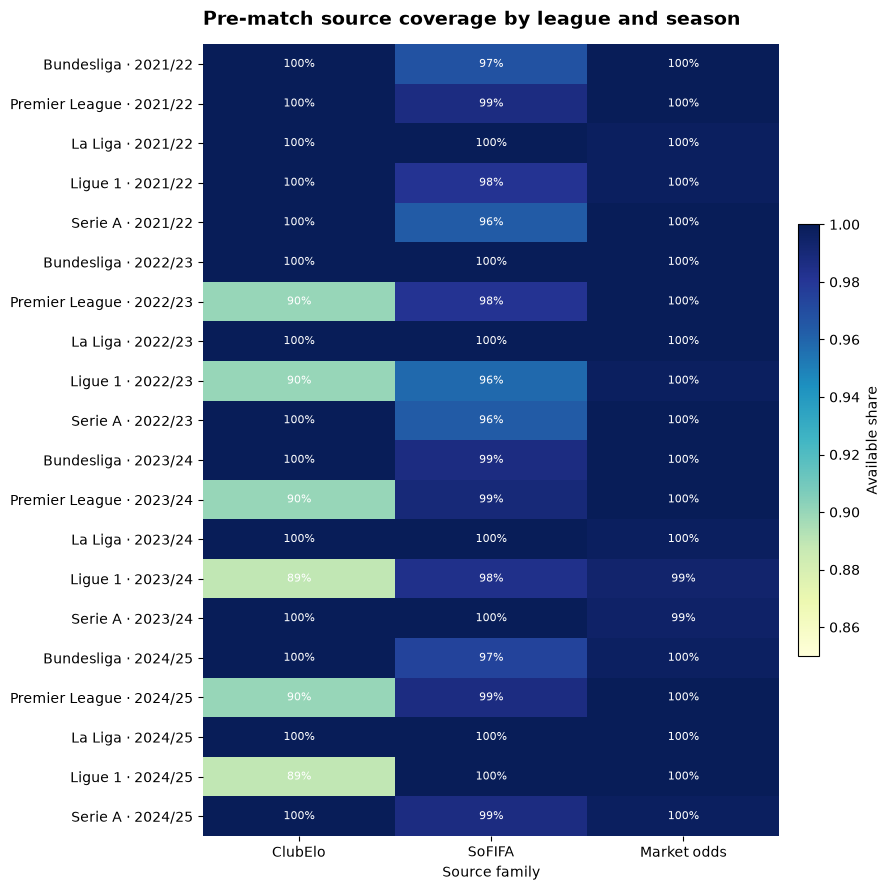

In [10]:
coverage_plot = coverage.copy()
league_names = {
    "EPL": "Premier League",
    "LALIGA": "La Liga",
    "BUNDESLIGA": "Bundesliga",
    "SERIE_A": "Serie A",
    "LIGUE_1": "Ligue 1",
}
coverage_plot["league_season"] = (
    coverage_plot["league_id"].map(league_names) + " · "
    + coverage_plot["season_id"].astype(str) + "/"
    + (coverage_plot["season_id"] + 1).astype(str).str[-2:]
)
heat = coverage_plot.set_index("league_season")[[
    "clubelo_coverage", "sofifa_coverage", "market_coverage"
]].astype(float)

fig, ax = plt.subplots(figsize=(9, 9))
image = ax.imshow(heat.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0.85, vmax=1)
ax.set_xticks(range(3), ["ClubElo", "SoFIFA", "Market odds"])
ax.set_yticks(range(len(heat)), heat.index)
ax.set_title("Pre-match source coverage by league and season", loc="left", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Source family")
ax.set_ylabel("")
for row in range(heat.shape[0]):
    for column in range(heat.shape[1]):
        value = heat.iat[row, column]
        ax.text(column, row, f"{value:.0%}", ha="center", va="center", color="white" if value > 0.72 else "#1F2933", fontsize=8)
colorbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.03)
colorbar.set_label("Available share")
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
plt.show()

Coverage below 100% is not repaired by looking forward. Later notebooks either impute values within a training pipeline or omit a source-specific feature when it is unavailable. In particular, the structural branch remains usable without market odds, while the market-enriched branch is evaluated only where a valid pre-match market row exists.

## 8. Fixed time roles and the final 2024/25 prediction horizon

In this project, `season_id` stores the **starting calendar year**. Therefore, `season_id = 2024` means the 2024/25 football season rather than the 2024 calendar year.

The next table defines exactly what “predicting the 2024/25 season” means in the stored match data. Expected fixture counts follow the double round-robin format: 380 matches for a 20-team league and 306 for an 18-team league. The first and last dates are calculated from the actual source rows and are not typed manually.

In [11]:
league_order = ["EPL", "LALIGA", "BUNDESLIGA", "SERIE_A", "LIGUE_1"]
expected_matches = {"EPL": 380, "LALIGA": 380, "BUNDESLIGA": 306, "SERIE_A": 380, "LIGUE_1": 306}

final_season = matches.loc[matches["season_id"].eq(FINAL_TEST_SEASON)].copy()
prediction_horizon = (
    final_season.groupby("league_id", observed=True)
    .agg(
        matches_to_predict=("game_id", "size"),
        first_match=("date", "min"),
        last_match=("date", "max"),
        unique_match_dates=("date", "nunique"),
    )
    .reindex(league_order)
    .reset_index()
)
prediction_horizon["expected_matches"] = prediction_horizon["league_id"].map(expected_matches)
prediction_horizon["count_difference"] = prediction_horizon["matches_to_predict"] - prediction_horizon["expected_matches"]

total_row = pd.DataFrame(
    {
        "league_id": ["ALL FIVE LEAGUES"],
        "matches_to_predict": [len(final_season)],
        "first_match": [final_season["date"].min()],
        "last_match": [final_season["date"].max()],
        "unique_match_dates": [final_season["date"].nunique()],
        "expected_matches": [sum(expected_matches.values())],
        "count_difference": [len(final_season) - sum(expected_matches.values())],
    }
)
prediction_horizon = pd.concat([prediction_horizon, total_row], ignore_index=True)
prediction_horizon.style.format(
    {
        "matches_to_predict": "{:,}",
        "expected_matches": "{:,}",
        "first_match": lambda value: value.strftime("%d %B %Y"),
        "last_match": lambda value: value.strftime("%d %B %Y"),
    }
)

,league_id,matches_to_predict,first_match,last_match,unique_match_dates,expected_matches,count_difference
0,EPL,380,16 August 2024,25 May 2025,109,380,0
1,LALIGA,380,15 August 2024,25 May 2025,142,380,0
2,BUNDESLIGA,306,23 August 2024,17 May 2025,97,306,0
3,SERIE_A,380,17 August 2024,25 May 2025,134,380,0
4,LIGUE_1,306,16 August 2024,17 May 2025,100,306,0
5,ALL FIVE LEAGUES,"1,752",15 August 2024,25 May 2025,185,"1,752",0


The resulting final test contains **1,752 matches**. Across all five leagues, prediction starts on **15 August 2024** and ends on **25 May 2025**. League-specific intervals differ because the competitions did not begin and finish on the same dates. A zero `count_difference` confirms that the stored sample contains the complete expected league schedules.

The `unique_match_dates` column is descriptive only. Notebook 06 will form chronological prediction/refit blocks carefully, because postponed fixtures mean that a calendar date is not always identical to a complete matchday.

### 8.1 Season-role counts

This final table makes the separation between context, development, final testing, and out-of-study rows visible. It is a safeguard against accidentally treating all available history as one random training sample.

In [12]:
role_counts = (
    matches.groupby(["season_id", "sample_role"], observed=True)
    .size()
    .rename("matches")
    .reset_index()
)
role_counts["season"] = role_counts["season_id"].astype(str) + "/" + (role_counts["season_id"] + 1).astype(str).str[-2:]
role_counts[["season", "sample_role", "matches"]].style.format({"matches": "{:,}"})

,season,sample_role,matches
0,2015/16,context_only,"1,826"
1,2016/17,context_only,"1,825"
2,2017/18,context_only,"1,826"
3,2018/19,context_only,"1,826"
4,2019/20,context_only,"1,725"
5,2020/21,context_only,"1,826"
6,2021/22,development,"1,826"
7,2022/23,development,"1,826"
8,2023/24,development,"1,752"
9,2024/25,walk_forward_test,"1,752"


Only the rows labelled `development` may be used for feature selection, algorithm comparison, hyperparameter tuning, and calibration. The 2024/25 results are opened once, after those choices are locked, in the walk-forward evaluation.

## 9. Save the essential interim dataset

The merged table is stored once as UTF-8 CSV. No feature manifest, data-availability export, or Parquet duplicate is created. Notebook 02 will read this file and add leakage-safe features.

In [13]:
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
output_path = INTERIM_DATA_DIR / "base_matches.csv"
matches.to_csv(output_path, index=False, encoding="utf-8", date_format="%Y-%m-%d")

print(f"Saved: {output_path}")
print(f"Rows: {len(matches):,}")
print(f"Columns: {matches.shape[1]}")
print(f"Final-test matches: {len(final_season):,}")

Saved: C:\Users\cerve\Desktop\DP\match_prediction\data\interim\base_matches.csv
Rows: 19,761
Columns: 88
Final-test matches: 1,752


## 10. Conclusion

The prepared table has one row per match and combines outcomes with three external pre-match information families. The joins preserve unique match identifiers, the market probabilities are internally coherent, and the dated ClubElo and SoFIFA observations do not start after the match they describe. Source incompleteness remains visible rather than being filled from future observations.

Most importantly, the empirical design is now explicit: model development uses 2021/22–2023/24, while the untouched 2024/25 walk-forward test consists of 1,752 fixtures between 15 August 2024 and 25 May 2025. Notebook 02 next transforms historical match information into pre-match features and explains every constructed variable family.